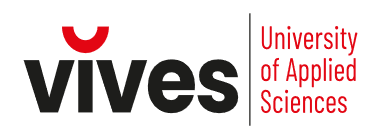<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **SUPPORT VECTOR MACHINES: INTRODUCTION**

Import statements

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

## **Linear SVC**

Generate dataset using `make_blobs`

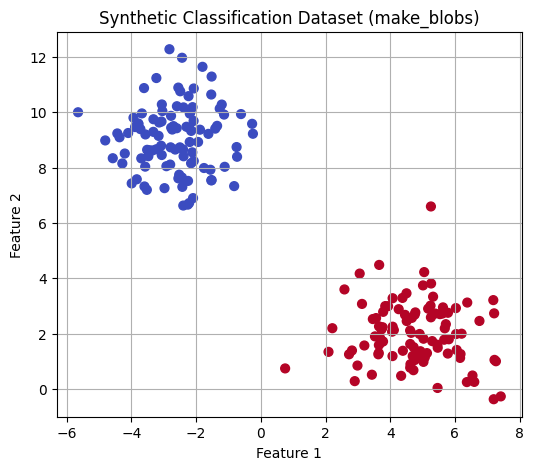

In [2]:
# two moderately separated clusters
X, y = make_blobs(n_samples=200,
                  centers=2,
                  cluster_std=1.2,
                  random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=40)
plt.title("Synthetic Classification Dataset (make_blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid();

The dataset is linearly separable because there is no overlap

Apply a hard margin SVC

In [3]:
hard_margin_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C=1e10, loss="hinge", random_state=42))  # very large C!
])

hard_margin_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 LinearSVC(C=10000000000.0, loss='hinge', random_state=42))])

A true hard‑margin SVC only works when the data are perfectly linearly separable. In Scikit‑Learn we simulate a hard margin by setting C extremely large, so the model penalizes any misclassification.

Apply a soft-margin SVC

In [4]:
soft_margin_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C=0.1, loss="hinge", random_state=42))  # small C
])

soft_margin_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', LinearSVC(C=0.1, loss='hinge', random_state=42))])

In the soft‑margin setting:

- Small C → more regularization → wide margin → allows some errors → better generalization
- Large C → less regularization → narrow margin → tries to classify everything correctly → risk of overfitting

Helper function to plot decision boundary (+ street)

In [5]:
def plot_svm_decision_boundary(clf, X, y, title, ax=None):

    if ax:
        plt.sca(ax)
    else:
        plt.figure(figsize=(6,5))
        ax = plt.gca()

    ax.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=40)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid
    xx = np.linspace(xlim[0], xlim[1], 200)
    yy = np.linspace(ylim[0], ylim[1], 200)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = clf.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, colors="k",
               levels=[-1, 0, 1],
               linestyles=["--", "-", "--"])

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid()

Compare hard-margin SVC vs soft-margin SVC

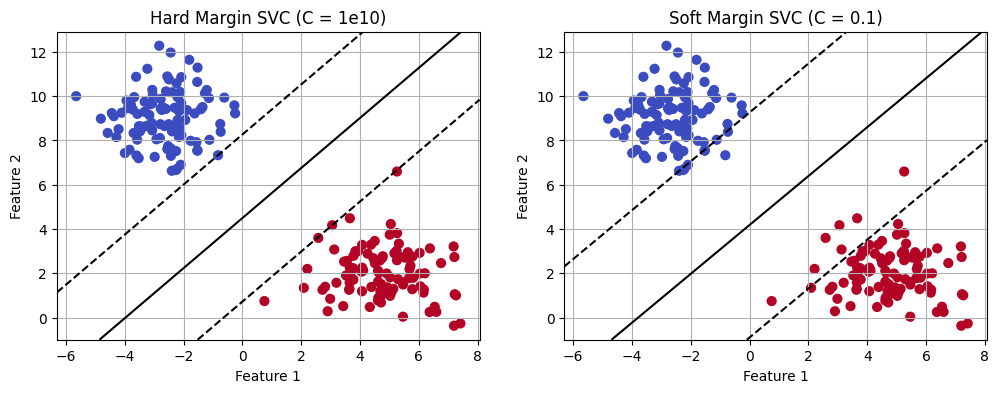

In [6]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_svm_decision_boundary(hard_margin_clf, X, y,
                           "Hard Margin SVC (C = 1e10)", ax=ax1)
plot_svm_decision_boundary(soft_margin_clf, X, y,
                           "Soft Margin SVC (C = 0.1)", ax=ax2)

The effect of C

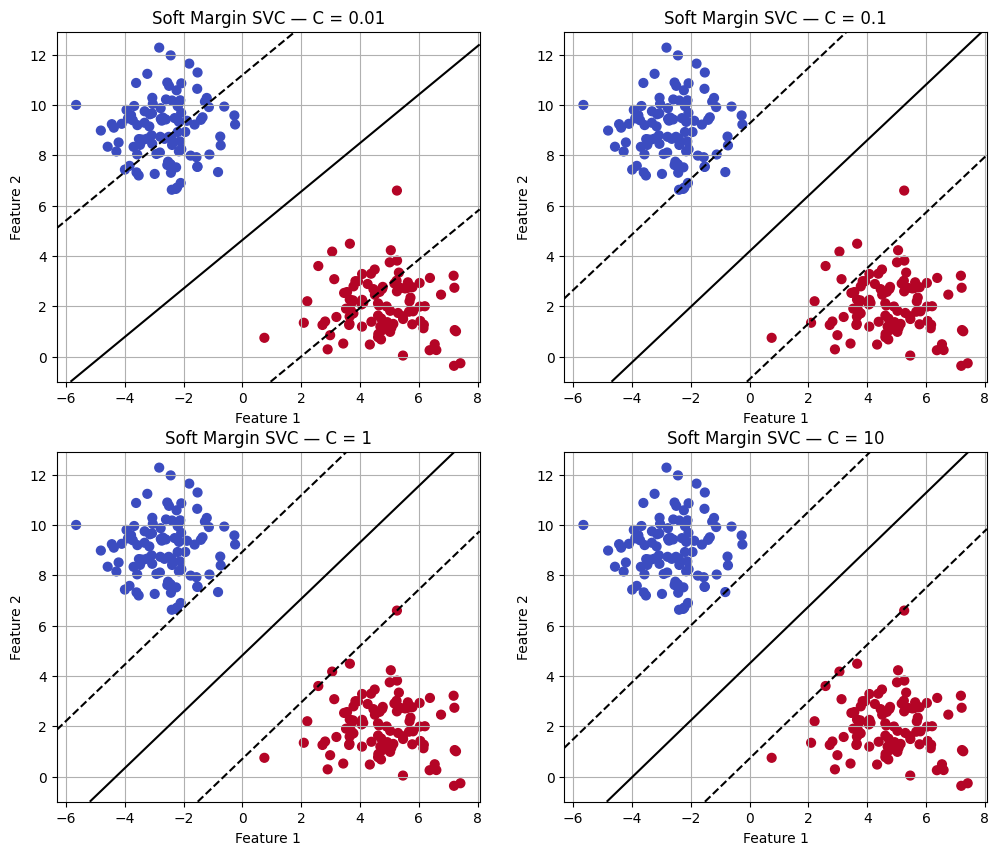

In [7]:
C_values = [0.01, 0.1, 1, 10]

_, axes = plt.subplots(2, 2, figsize=(12, 10))

for C, ax in zip(C_values, axes.flatten()):
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(C=C, loss="hinge", random_state=42))
    ])
    clf.fit(X, y)
    plot_svm_decision_boundary(clf, X, y, f"Soft Margin SVC — C = {C}", ax=ax)

**Conclusions**

Hard Margin SVC

- Requires the dataset to be perfectly linearly separable
- Does not tolerate classification errors
- Extremely sensitive to outliers

Soft Margin SVC

- Introduces a balance between margin width and misclassification
- Controlled by C, the regularization hyperparameter
- Small C → wide margin → more robust → less overfitting
- Large C → narrow margin → tries to classify all points correctly → may overfit

## **Nonlinear SVC**

Generate dataset using `make_moons`

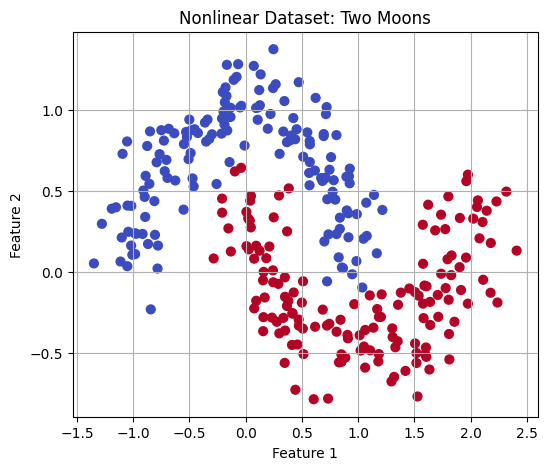

In [8]:
X_moon, y_moon = make_moons(n_samples=300, noise=0.15, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap="coolwarm", s=40)
plt.title("Nonlinear Dataset: Two Moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid();

Linear SVC with polynomial features

0.97

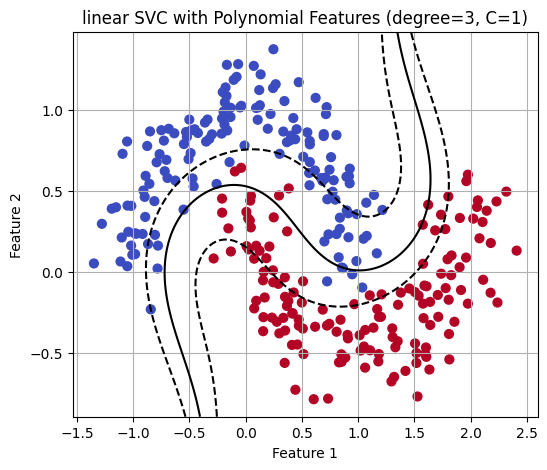

In [9]:
poly = Pipeline([
    ("polynomial_features", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1.0, loss="hinge")),
])
poly.fit(X_moon, y_moon)
plot_svm_decision_boundary(poly, X_moon, y_moon,
                           "linear SVC with Polynomial Features (degree=3, C=1)")
poly.score(X_moon, y_moon)  # accuracy

Polynomial kernel SVC

0.9766666666666667

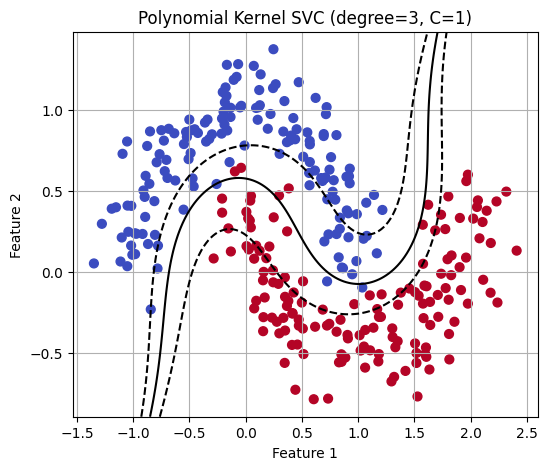

In [10]:
poly_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", degree=3, coef0=1.0, C=1.0))
])

poly_svm.fit(X_moon, y_moon)

plot_svm_decision_boundary(poly_svm, X_moon, y_moon,
                           "Polynomial Kernel SVC (degree=3, C=1)")
poly_svm.score(X_moon, y_moon)  # accuracy

Overfitting:
- High degree → boundary becomes wiggly
- Large C → almost no errors allowed → boundary adapts too much to noise

1.0

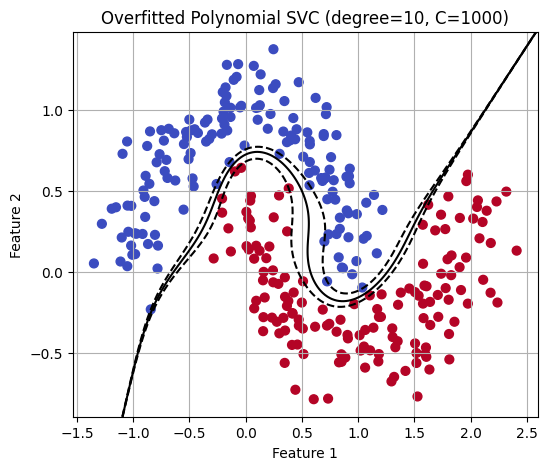

In [11]:
overfit_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", degree=10, coef0=1, C=1000))
])

overfit_svm.fit(X_moon, y_moon)

plot_svm_decision_boundary(overfit_svm, X_moon, y_moon,
                           "Overfitted Polynomial SVC (degree=10, C=1000)")
overfit_svm.score(X_moon, y_moon)  # acc

Underfitting:
- Low degree → smooth decision boundary
- Small C → wide margin → low sensitivity to noise


0.8533333333333334

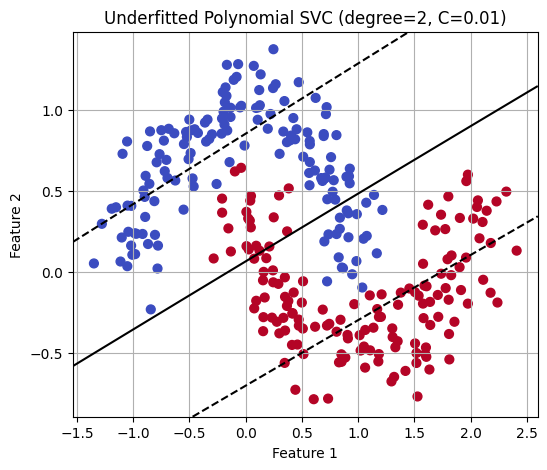

In [12]:
underfit_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", degree=2, coef0=1, C=0.01))
])

underfit_svm.fit(X_moon, y_moon)

plot_svm_decision_boundary(underfit_svm, X_moon, y_moon,
                           "Underfitted Polynomial SVC (degree=2, C=0.01)")
underfit_svm.score(X_moon, y_moon)  # acc

Tune hyperparameters (degree and C) using grid search and cross-validation

In [13]:
# Pipeline for polynomial kernel SVC
poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", coef0=1))
])

# Hyperparameter grid
param_grid = {
    "svm__degree": [2, 3, 4, 5],
    "svm__C": [0.1, 1, 10, 100, 1000]
}

grid_search = GridSearchCV(
    poly_pipeline,
    param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_moon, y_moon)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'svm__C': 100, 'svm__degree': 3}
Best cross-validation accuracy: 0.99


Visualize best model

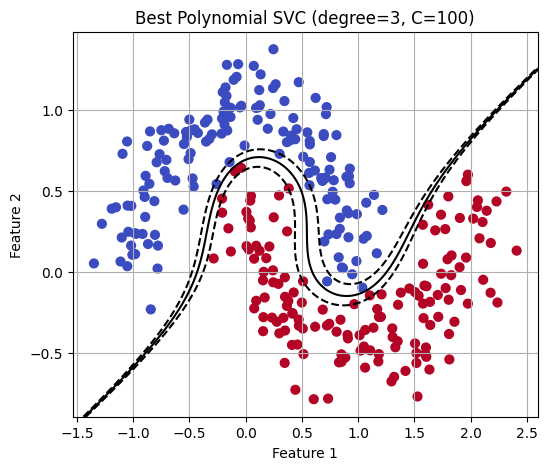

In [14]:
best_model = grid_search.best_estimator_

plot_svm_decision_boundary(
    best_model,
    X_moon,
    y_moon,
    title=f"Best Polynomial SVC (degree={grid_search.best_params_['svm__degree']}, "
          f"C={grid_search.best_params_['svm__C']})"
)

**Conclusions**

Why Polynomial SVC?

- Linear SVC can’t handle curved boundaries.
- Polynomial kernels model nonlinear relationships without manually adding features.

How Overfitting Appears?

- Decision boundary becomes extremely irregular (“wiggly”).
- Caused by large C or high polynomial degree.

How to Fix It?

- Reduce C → stronger regularization, smoother boundary.
- Lower degree → simpler model, less variance.
- Balance is key — complex enough to fit the signal, simple enough to ignore noise.
- Tune hyperparameters using validation set or cross-validation.
- Use grid search to systematically try many combinations of hyperparameters.

---